# MCQ Answering


## Setups


### Install Libraries


In [ ]:
import json
import os
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
from prettytable import PrettyTable
from pyvis.network import Network

import kgraph as kg

### Visualization


In [ ]:
def custom_draw_graph(
    G: kg.KB,
    title: str,
    colored_nodes: list[str] | None,
    colored_edges: list[dict[str, str]] | None,
    outdir="out",
    verbose=False,
):
    """
    Visualize KB object with specified colored nodes & edges.

    Parameters
    ----------
    G: kg.KB
    title: str
    colored_nodes: list[str]
        List of nodes to colorize orange.
    colored_edges: list[dict[str, str]]
        List of edges to colorize orange.
    outdir: str (optional)

    Return
    ------
    None. However, this function generates an HTML file during execution.
    """
    nt = Network(directed=True, height="90%")
    if colored_nodes is None:
        colored_nodes = G.get_nodes()  # for PG, all nodes will be orange
    if colored_edges is None:
        colored_edges = []  # No edges will be orange if not specified

    # add relations to graph
    for link in G.relations:
        head = link["head"]
        tail = link["tail"]
        label = link["type"]

        # add nodes
        if head in colored_nodes:
            nt.add_node(head, size=10, color="orange")
        else:
            nt.add_node(head, size=10)

        if tail in colored_nodes:
            nt.add_node(tail, size=10, color="orange")
        else:
            nt.add_node(tail, size=10)

        # add edges
        if head in colored_nodes and tail in colored_nodes:
            # edges between orange nodes
            # Note: head & tail are both orange
            V = kg.KB(colored_edges)  # KB created from verified rels
            rels = [rel["type"] for rel in V.get_relations_between(head, tail)]
            if label in rels:
                nt.add_edge(head, tail, label=label, color="orange")
            else:
                nt.add_edge(head, tail, label=label, color="gray", dashes=True)

        else:
            # edges between gray nodes.
            # Note: head or tail could be orange
            if verbose:
                print("Adding edge between gray nodes.")
            nt.add_edge(head, tail, title=label, color="gray")

    # create outdir if not exist
    if not os.path.exists(outdir):
        os.makedirs(outdir)

    # create HTML
    # nt.show_buttons(True)
    nt.save_graph("{}/{}.html".format(outdir, title))

In [ ]:
def plot_result(
    data_dict: dict[str, dict[str, int]], title: str, lang: Literal["ja", "en"] = "en"
):
    """
    A function to plot each choice on a plane with node similarity and edge match rate as axes.

    Parameters
    ----------
    data_dict: dict[str, dict[str, int]]
        A dictionary which stores node & edge scores for each choice. For example:
        ```Python
        data = {
            'Barack Obama': {'node_score': 0.8987955152988434, 'edge_score': 1.0},
            'George W. Bush': {'node_score': 0.8650993903477987, 'edge_score': 1.0},
            'Joe Biden': {'node_score': 0.8217522501945496, 'edge_score': 1.0},
            'Bill Clinton': {'node_score': 0.856591135263443, 'edge_score': 1.0}
        }
        ```
    title: str
        Title of graph.
    lang: Literal["ja", "en"]
        Specify language from Japanese or English.
    """
    # プロット
    for person, scores in data_dict.items():
        node_score = scores["node_score"]
        edge_score = scores["edge_score"]
        plt.scatter(node_score, edge_score, label=person, marker="o", s=80)

    # Range
    plt.xlim(0.0, 1.05)
    plt.ylim(0.0, 1.05)

    # labels
    match lang:
        case "ja":
            plt.xlabel("ノード類似度", fontsize=17)
            plt.ylabel("エッジ一致率", fontsize=17)
        case "en":
            plt.xlabel("Node similarity", fontsize=17)
            plt.ylabel("Verified edge ratio", fontsize=17)
        case _:
            raise ValueError("Invalid language specified.")

    # settings
    plt.tick_params(labelsize=15)
    plt.grid(True)
    plt.title(title, fontsize=17)
    plt.legend(fontsize="xx-large")

    # hide right and top spines
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["top"].set_visible(False)

    # visualize graph
    plt.show()

### CUI


In [ ]:
def print_exp_result(result: dict):
    table = PrettyTable()
    table.field_names = ["Person", "Node Score", "Edge Score"]

    for person, scores in result.items():
        table.add_row([person, scores["node_score"], scores["edge_score"]])

    print(f"\n{table}")

### MCQ solver


In [ ]:
def swap_label_with_symbol(PG: kg.KB, org_l: str, new_l: str) -> kg.KB:
    """
    Swap specified node label in PG with special symbol "#BLANK".
    """
    rels = []
    for r in PG.relations:
        # replace `org_l` in head & tail
        hd = r["head"].replace(org_l, new_l)
        tl = r["tail"].replace(org_l, new_l)
        rels.append({"head": hd, "type": r["type"], "tail": tl})

    new_PG = kg.KB(rels)
    return new_PG


def find_best_choice(choice: list[str], result: dict[str, dict[str, int]]) -> int:
    """
    Function to find the best choice based on the result of fact verification.

    Parameters
    ----------
    choice: list[str]
        List of choices.
    result: dict[str, dict[str, int]]
        A dictionary which stores node & edge scores for each choice.

    Return
    ------
    ans_id: int
        Index of the best choice. If not able to choose answer, return -1.
    """
    node_scores = np.array([result[c]["node_score"] for c in choice])
    edge_scores = np.array([result[c]["edge_score"] for c in choice])

    if np.any(edge_scores > 0.0):
        max_escore = np.max(edge_scores)
        max_id = np.where(edge_scores == max_escore)[0]
        if max_id.size == 1:
            return max_id.item()
        else:
            node_scores = node_scores[max_id]
            max_nscore = np.max(node_scores)
            max_id = np.where(node_scores == max_nscore)[0]
            if max_id.size == 1:
                return max_id.item()
            else:
                return -1
    else:
        return -1


def cond_exp(
    mcq_id: str, sentence: str, choice: list[str], use_cache: bool = True, verbose=False
) -> tuple[dict[str, tuple[float, float]], int]:
    """
    Toplevel function to conduct experiment.

    Parameters
    ----------
    mcq_id: str
    sentence: str
        Problem sentence i.e. mcq(x).
    choice: list[str]
        List of choices (C)
    use_cache: bool (optional)
        Use cache or not.
    verbose: bool (optional)
        Print debug information or not.

    Return
    ------
    result: dict[str, tuple[float, float]]
        A dictionary which stores node & edge scores for each choice. For example:
        ```JSON
        {
            "id": "hf-1",
            "result": {
                "Nelson Mandela": {
                    "node_score": 0.8369905948638916,
                    "edge_score": 0.0
                },
                "Rosa Parks": {
                    "node_score": 0.8717791736125946,
                    "edge_score": 0.0
                },
                "Martin Luther King Jr.": {
                    "node_score": 0.8717791885137558,
                    "edge_score": 0.2
                },
                "Malcolm X": {
                    "node_score": 0.8717791736125946,
                    "edge_score": 0.0
                }
            }
        }
        ```
    ans_id: int
        Index of the best choice. If not able to choose answer, return -1.
    """

    # --- Step1. Create MCQ template ---
    print("Creating PG template...", end="", flush=True)
    BLANK_SYMBOL = "#BLANK"
    PGs = [
        swap_label_with_symbol(kg.from_text_to_kb(sentence.format(c)), c, BLANK_SYMBOL)
        for c in choice
    ]

    PG_temp = kg.KB()
    for PG in PGs:
        PG_temp = kg.join(PG_temp, PG)
    print("\rPG_temp:                \n{}".format(PG_temp))

    # --- Verify each proposition ---
    result = {}
    for c in choice:
        # --- Step 1-1. Create PG ---
        PG = swap_label_with_symbol(PG_temp, BLANK_SYMBOL, c)
        print("\nCreated PG")

        # --- Step 1-2. Create KG ---
        # construct KG from Wikipedia
        titles = sorted(PG.get_nodes())
        KG = kg.KB()
        references = []
        print("Creating KG...")
        for title in titles:
            g, _, url = kg.wiki_summary_to_kb(title, use_cache=use_cache, verbose=verbose)
            KG = kg.join(KG, g)
            references.append({"title": title, "url": url})
        print("\rCreated KG from:")
        for ref in references:
            print("\t- {} ({})".format(ref["title"], ref["url"]))

        # --- Step 2. Node matching ---
        subnodes, Vp, matching_score = kg.get_subgraph_nodes(KG.get_nodes(), PG.get_nodes())

        # --- Step 3. Estimate truthfulness ---
        verify_score, verified_rels, evidence_rels = kg.verify_proposition(PG, KG)
        if verbose:
            print("verify score = {}".format(verify_score))

        # draw graphs by pyvis.network
        custom_draw_graph(PG, "{}_PG_{}".format(mcq_id, c), Vp, verified_rels)
        custom_draw_graph(KG, "{}_KG_{}".format(mcq_id, c), subnodes, evidence_rels)

        result[c] = {"node_score": matching_score, "edge_score": verify_score}

    # find best choice
    ans_id = find_best_choice(choice, result)

    return result, ans_id

### Experiment using MCQ-data file (json)


In [ ]:
def write_results_to_json(results: list, filename: str):
    """
    Write results to a JSON file.

    Parameters
    ----------
    results: List[Dict[str, Any]]
        A list containing data to be written to the JSON file.
    filename: str
        Path to the JSON file to write.
    """
    try:
        with open(filename, "w", encoding="utf-8") as json_file:
            json.dump(results, json_file, ensure_ascii=False, indent=4)
        print(f"Results written to {filename} successfully.")
    except Exception as e:
        print(f"Error writing results to {filename}: {e}")

In [ ]:
def exp_from_json(file_path: str, use_cache: bool = True, lang: Literal["ja", "en"] = "en"):
    """
    Conduct experiment for all questions in the JSON file.

    Parameters
    ----------
    file_path: str
        Path to the JSON file which stores MCQ data.
    use_cache: bool
        If True, use cache to construct KGs.
    lang: Literal["ja", "en"]
        Specify language for the scatter plot (Japanese or English).
    """

    if os.path.isfile(file_path):
        with open(file_path, "r", encoding="utf-8") as file:
            data = json.load(file)
    else:
        raise FileNotFoundError("MCQ data file '{}' was not found.".format(file_path))

    results = []

    for mcq in data:
        # solve each MCQ
        print("Solving '{}'".format(mcq["id"]))
        print("sentence: {}".format(mcq["sentence"]))
        result, ans_id = cond_exp(mcq["id"], mcq["sentence"], mcq["choice"], use_cache=use_cache)
        correct = ans_id == mcq["answer"]

        # print result
        print("Answer: {} ({})".format(ans_id, "correct" if correct else "incorrect"))
        print_exp_result(result)
        plot_result(result, title=mcq["id"], lang=lang)

        # Save result in json
        results.append({"id": mcq["id"], "result": result, "answer": ans_id, "correct": correct})
        outdir = os.environ["HOME"] + "/github/mcq-generator/experiments/11_mcq_ansering/result"
        title = os.path.basename(file_path).replace("mcq", "result")
        write_results_to_json(results, filename=os.path.join(outdir, title))

    # summary of results
    correct_count = sum([1 for r in results if r["correct"]])
    print("Answered correctly for {}/{} questions.".format(correct_count, len(results)))

#### Single excution


In [ ]:
def single_exp_from_json(
    file_path: str, id: str, use_cache=True, lang: Literal["ja", "en"] = "en"
):
    """
    Function to conduct single experiment from JSON file.

    Parameters
    ----------
    file_path: str
        Path to the JSON file which stores MCQ data.
    id: str
        ID of MCQ to solve.
    use_cache: bool
        If True, use cache to construct KGs.
    lang: Literal["ja", "en"]
        Specify language for the scatter plot (Japanese or English).
    """
    if os.path.isfile(file_path):
        with open(file_path, "r", encoding="utf-8") as file:
            data = json.load(file)
    else:
        raise FileNotFoundError("MCQ data file '{}' was not found.".format(file_path))

    for mcq in data:
        if mcq["id"] == id:
            print("Solving '{}'".format(mcq["id"]))
            print("sentence: {}".format(mcq["sentence"]))
            result, ans_id = cond_exp(
                mcq["id"], mcq["sentence"], mcq["choice"], use_cache=use_cache
            )
            print(
                "Answer: {} ({})".format(
                    ans_id, "correct" if ans_id == mcq["answer"] else "incorrect"
                )
            )
            print_exp_result(result)
            plot_result(result, title=mcq["id"], lang=lang)

In [15]:
%env TOKENIZERS_PARALLELISM=false

env: TOKENIZERS_PARALLELISM=false


## 動作テスト


json を読み込み、指定された id の問題で実験


Solving 'his-1'
sentence: The first president of the United States was {}.
PG_temp:                
{'head': '#BLANK', 'type': 'position held', 'tail': 'president of the United States'},
{'head': 'president of the United States', 'type': 'officeholder', 'tail': '#BLANK'},
{'head': 'first president of the United States', 'type': 'officeholder', 'tail': '#BLANK'}

Created PG
Creating KG...
Created KG from:
	- Abraham Lincoln (https://en.wikipedia.org/wiki/Abraham_Lincoln)
	- first president of the United States (https://en.wikipedia.org/wiki/George_Washington)
	- president of the United States (https://en.wikipedia.org/wiki/President_of_the_United_States)

Created PG
Creating KG...
Created KG from:
	- Thomas Jefferson (https://en.wikipedia.org/wiki/Thomas_Jefferson)
	- first president of the United States (https://en.wikipedia.org/wiki/George_Washington)
	- president of the United States (https://en.wikipedia.org/wiki/President_of_the_United_States)

Created PG
Creating KG...
Created KG 

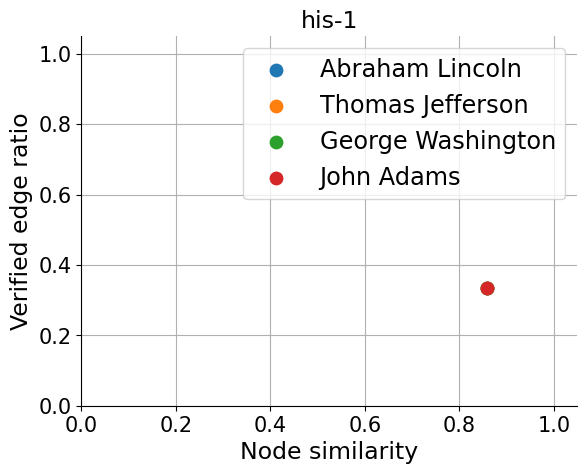

In [ ]:
if True:
    single_exp_from_json("dataset/MCQs.json", "his-1", use_cache=False)

## Experiment
